## Extracting On-Chain Data with Dune (SIM) & CoinGecko APIs
### What you will learn 
- How to use the **Dune Analytics (SIM) API** to query blockchain data
- How to use the **CoinGecko API** to fetch market and token data

### What is the Dune SIM API?
The Dune SIM API is a real-time blockchain data API. Unlike the classic Dune SQL query API, SIM gives you INSTANT structured on-chain data, no SQL, no waiting.
### What can you fetch?
- Wallet transactions        → /evm/transactions/{address}
- Token balances             → /evm/balances/{address}
- Token transfers            → /evm/token-transfers/{address}
- NFT holdings               → /evm/nft-balances/{address}

### How It Works:
Your Python Code → SIM API → Live Blockchain Data → JSON → DataFrame

Base URL: https://api.sim.dune.com/v1
Docs: https://docs.sim.dune.com


### CoinGecko API
CoinGecko is a cryptocurrency market data platform. Its API provides:
- Current prices for thousands of tokens
- Historical OHLC (candlestick) price data
- Market cap, volume, and more
- Token metadata (description, contract addresses, links)

### Free vs Pro API
| Feature          | Free              | Pro        |
|------------------|-------------------|------------|
| Rate limit       | ~10–30 calls/min  | Higher     |
| API key required | No (recommended)  | Yes        |
| Historical data  | Limited           | Extended   |

### API Keys:
- Dune Analytics → https://sim.dune.com → Sign up → API Keys
- CoinGecko      → https://www.coingecko.com/en/api → Free or Pro API key

### Step 1: Install required libaries
#### ! pip install requests pandas python-dotenv matplotlib
- `requests`      → makes HTTP API calls
- `pandas`        → handles tabular data
- `python-dotenv` → loads API keys from a .env file safely
- `matplotlib`    → creates charts

### Step 2: Create a .env File for Your API Keys
- DUNE_API_KEY=your_dune_api_key_here
- COINGECKO_API_KEY=your_coingecko_api_key_here
#### IMPORTANT: Add .env to your .gitignore so you never upload keys to GitHub

### Step 3: Import All Libraries

In [1]:
! pip install requests pandas python-dotenv matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import requests                  # HTTP requests to APIs
import pandas as pd              # Data manipulation
import time                      # Adding delays to respect rate limits
import json                      # Parsing JSON responses
import matplotlib.pyplot as plt  # Charts
from datetime import datetime    # Timestamps for filenames
 
print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
import os
from dotenv import load_dotenv

# Load environment variables from the .env file in this folder
load_dotenv()
 
# Read the API keys
DUNE_API_KEY = os.getenv("DUNE_API_KEY")
COINGECKO_API_KEY = os.getenv("COINGECKO_API_KEY")
 
# Confirm keys loaded - NEVER print the actual key value!
print("Dune API Key loaded :", "Yes" if DUNE_API_KEY      else " Not found")
print("CoinGecko API Key loaded:", "Yes" if COINGECKO_API_KEY else " Not found")

Dune API Key loaded : Yes
CoinGecko API Key loaded: Yes


### DUNE SIM

In [4]:
# Base URL for ALL Dune SIM API calls
SIM_BASE_URL = "https://api.sim.dune.com/v1"
 
# Authentication header - required on every request
sim_headers = {
    "X-Sim-Api-Key": DUNE_API_KEY
}
 
print("Dune SIM API configuration ready")
print(f"Base URL: {SIM_BASE_URL}")

Dune SIM API configuration ready
Base URL: https://api.sim.dune.com/v1


In [5]:
def get_wallet_transactions(address, limit=100, chain_ids="1"):
    """
    Fetch all EVM transactions for a wallet address.
 
    address   : str - The wallet address (0x...)
    limit     : int - Max transactions to return
    chain_id : str  - Ethereum

    Common chain IDs:
        "1"     = Ethereum mainnet
        "137"   = Polygon
        "10"    = Optimism
        "42161" = Arbitrum
        "8453"  = Base
    """
    url    = f"{SIM_BASE_URL}/evm/transactions/{address}"
    
    params = {"limit": limit}
 
    if chain_ids:
        params["chain_ids"] = chain_ids  # Filter to specific chains
 
    response = requests.get(url, headers=sim_headers, params=params)
 
    if response.status_code == 200:
        data = response.json()
        txs  = data.get("transactions", [])
        df   = pd.DataFrame(txs)
        print(f"Fetched {len(df)} transactions for {address[:10]}…")
        return df, data  # return raw data too for pagination
    else:
        print(f"Error {response.status_code}: {response.text}")
        return None, None

In [7]:
WALLET_ADDRESS = "0x76e6f8462FCE5985D1a900bAe01D9b7a187cDF66"
 
df_txs, raw_response = get_wallet_transactions(WALLET_ADDRESS, limit=100)
print(df_txs.head(5))

print("📊 Shape:", df_txs.shape)
print("\n📋 Columns:\n", df_txs.columns.tolist())
print("\n🔍 Data types:\n", df_txs.dtypes)
print("\n📄 First row (full detail):")
print(df_txs.iloc[0].to_dict())

Fetched 100 transactions for 0x76e6f846…
      chain  chain_id                                     address  \
0  ethereum         1  0x76e6f8462fce5985d1a900bae01d9b7a187cdf66   
1  ethereum         1  0x76e6f8462fce5985d1a900bae01d9b7a187cdf66   
2  ethereum         1  0x76e6f8462fce5985d1a900bae01d9b7a187cdf66   
3  ethereum         1  0x76e6f8462fce5985d1a900bae01d9b7a187cdf66   
4  ethereum         1  0x76e6f8462fce5985d1a900bae01d9b7a187cdf66   

                  block_time  block_number  index  \
0  2026-03-30T10:14:23+00:00      24769753    273   
1  2026-03-30T07:23:59+00:00      24768903    161   
2  2026-03-30T07:23:47+00:00      24768902    121   
3  2026-03-30T07:20:59+00:00      24768888    176   
4  2026-03-30T07:19:59+00:00      24768883    258   

                                                hash  \
0  0x7a45f206a153574d326cf77b43ee4c396b0b1cf5bd5d...   
1  0x13d41d844b4fc96b9baa7ce3d437240acf4d517dbb92...   
2  0xa45841763c4e2f049de8a7e3076d6a539b686c3573f9...   
3

In [8]:
df_txs

,chain,chain_id,address,block_time,block_number,index,hash,block_hash,value,transaction_type,from,to,nonce,gas_price,gas_used,effective_gas_price,success,data,logs
0,ethereum,1,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,2026-03-30T10:14:23+00:00,24769753,273,0x7a45f206a153574d326cf77b43ee4c396b0b1cf5bd5d...,0x96e6d1e77db685f8b9517ed467af72838028ca2437ee...,0x64ffe2e1b4f002,Sender,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,0xa3a079d21d5f8c648085e50b349ee1fe8159ac7b,0x103,0x954f8ab,0x5208,0x954f8ab,True,0x,[]
1,ethereum,1,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,2026-03-30T07:23:59+00:00,24768903,161,0x13d41d844b4fc96b9baa7ce3d437240acf4d517dbb92...,0xda5456104c3fa5a11603050f0f6ddde74e5e76f20fc4...,0x3b9aca00,Receiver,0xe88c31b3e399592a317aa483c74a6023ed516295,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,0x0,0x7da9f7e,0x5208,0x7da9f7e,True,0x,[]
2,ethereum,1,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,2026-03-30T07:23:47+00:00,24768902,121,0xa45841763c4e2f049de8a7e3076d6a539b686c3573f9...,0xa70f3063a83367c2cf9540728d729a30229ea0c0d6b0...,0x3b9aca00,Receiver,0x1d82007cdcf59546132ab1fab6582d8197e1ff1b,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,0x0,0x86bc222,0x5208,0x86bc222,True,0x,[]
3,ethereum,1,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,2026-03-30T07:20:59+00:00,24768888,176,0x6ef18e073d78fca9fc9466e04e71cd67cfedf2648cc3...,0x1567ef43e970c0979a702f9ea34575899c7831478b8a...,0x298a1f5e100,Receiver,0xe88027dd0d5487bbde4b1a5aa41fb75de26f1295,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,0x0,0x8a3021f,0x5208,0x8a3021f,True,0x,[]
4,ethereum,1,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,2026-03-30T07:19:59+00:00,24768883,258,0xbc1f2f7ad0ef5a8633c505b196b41f43a5910a0e71ec...,0xa220d101b405e95ce5f7e13734fc648f40181f30ae08...,0x3f62621ce7dc1b4,Sender,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,0xe88c5e8b6a4947153ccd25232aaf8ce6739b6295,0x102,0x9a1d8e4,0x5208,0x9a1d8e4,True,0x,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,ethereum,1,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,2026-02-12T02:49:23+00:00,24437816,294,0x24ccb74b541d9aab1c4d4bb67778c791994de74fa9eb...,0x511950183d03cdec4e93629c348c68f16c63411f90d8...,0x3b9aca00,Receiver,0xe41e8100fc684f34ca690cffd30d9526d869a8c7,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,0x9,0x36c4730,0x5208,0x36c4730,True,0x,[]
96,ethereum,1,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,2026-02-11T20:04:47+00:00,24435801,317,0x3c3214ecf9fbb3885d66b88dbe3a3527de33bd280387...,0xa5bf7bd660ff0c872748f4da671f2689317d505f948f...,0x3b9aca00,Receiver,0x470c482b95e7f40f89f82d774bea4ad2883528fd,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,0x5,0x6f5685a,0x5208,0x6f5685a,True,0x,[]
97,ethereum,1,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,2026-02-11T20:03:47+00:00,24435796,424,0x435d87e3ed4fbebdb5c62c90ec58e4a288a617a8f426...,0xeb7e890373ea1e589308bba3d768b4cb1dafae13a73c...,0x3b9aca00,Receiver,0x773c8a5b92325e10d514d96ad3cd28cc1e375a50,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,0x4,0x66c2889,0x5208,0x66c2889,True,0x,[]
98,ethereum,1,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,2026-02-11T16:34:11+00:00,24434753,236,0x6580dc16b5b53a5244df9a1c4e4c8d15a687a7b0269c...,0xf2b7b25dc2ce2e1fcfb248a194e9a8028ba7615cef9d...,0x3b9aca00,Receiver,0x36bce37eb50efd6f694da1b7dcf286af92601123,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,0x2,0x1018dc13,0x5208,0x1018dc13,True,0x,[]


In [10]:
df_clean = df_txs.copy()
 
# Convert block timestamp to readable datetime
if "block_time" in df_clean.columns:
    df_clean["block_time"] = pd.to_datetime(df_clean["block_time"])
    print("block_time converted to datetime")
 
# Convert value (ETH transferred) from string to float if needed
if "value" in df_clean.columns:
    df_clean["value"] = pd.to_numeric(df_clean["value"], errors="coerce")
    # ETH value is in Wei (1 ETH = 10^18 Wei) — convert to ETH
    df_clean["value_eth"] = df_clean["value"] / 1e18
    print("value converted from Wei to ETH")
 
# Convert gas fields to numeric
for col in ["gas", "gas_price", "gas_used"]:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")
 
# Sort by time — most recent first
if "block_time" in df_clean.columns:
    df_clean = df_clean.sort_values("block_time", ascending=False)
 
print(f"\n Cleaned DataFrame: {len(df_clean)} rows")
print(df_clean[["block_time", "from", "to", "value_eth"]].head(10))

block_time converted to datetime
value converted from Wei to ETH

 Cleaned DataFrame: 100 rows
                 block_time                                        from  \
0 2026-03-30 10:14:23+00:00  0x76e6f8462fce5985d1a900bae01d9b7a187cdf66   
1 2026-03-30 07:23:59+00:00  0xe88c31b3e399592a317aa483c74a6023ed516295   
2 2026-03-30 07:23:47+00:00  0x1d82007cdcf59546132ab1fab6582d8197e1ff1b   
3 2026-03-30 07:20:59+00:00  0xe88027dd0d5487bbde4b1a5aa41fb75de26f1295   
4 2026-03-30 07:19:59+00:00  0x76e6f8462fce5985d1a900bae01d9b7a187cdf66   
5 2026-03-30 07:19:59+00:00  0x1d8d082cab87e2d183b957b862cf93e44624af1b   
6 2026-03-30 07:19:35+00:00  0x76e6f8462fce5985d1a900bae01d9b7a187cdf66   
7 2026-03-27 19:16:59+00:00  0xf30ba13e4b04ce5dc4d254ae5fa95477800f0eb0   
8 2026-03-27 15:13:47+00:00  0xf30ba13e4b04ce5dc4d254ae5fa95477800f0eb0   
9 2026-03-27 09:39:35+00:00  0xf30ba13e4b04ce5dc4d254ae5fa95477800f0eb0   

                                           to  value_eth  
0  0xa3a079d21d5f8c6

In [11]:
df_clean

,chain,chain_id,address,block_time,block_number,index,hash,block_hash,value,transaction_type,from,to,nonce,gas_price,gas_used,effective_gas_price,success,data,logs,value_eth
0,ethereum,1,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,2026-03-30 10:14:23+00:00,24769753,273,0x7a45f206a153574d326cf77b43ee4c396b0b1cf5bd5d...,0x96e6d1e77db685f8b9517ed467af72838028ca2437ee...,NaN,Sender,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,0xa3a079d21d5f8c648085e50b349ee1fe8159ac7b,0x103,NaN,NaN,0x954f8ab,True,0x,[],NaN
1,ethereum,1,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,2026-03-30 07:23:59+00:00,24768903,161,0x13d41d844b4fc96b9baa7ce3d437240acf4d517dbb92...,0xda5456104c3fa5a11603050f0f6ddde74e5e76f20fc4...,NaN,Receiver,0xe88c31b3e399592a317aa483c74a6023ed516295,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,0x0,NaN,NaN,0x7da9f7e,True,0x,[],NaN
2,ethereum,1,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,2026-03-30 07:23:47+00:00,24768902,121,0xa45841763c4e2f049de8a7e3076d6a539b686c3573f9...,0xa70f3063a83367c2cf9540728d729a30229ea0c0d6b0...,NaN,Receiver,0x1d82007cdcf59546132ab1fab6582d8197e1ff1b,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,0x0,NaN,NaN,0x86bc222,True,0x,[],NaN
3,ethereum,1,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,2026-03-30 07:20:59+00:00,24768888,176,0x6ef18e073d78fca9fc9466e04e71cd67cfedf2648cc3...,0x1567ef43e970c0979a702f9ea34575899c7831478b8a...,NaN,Receiver,0xe88027dd0d5487bbde4b1a5aa41fb75de26f1295,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,0x0,NaN,NaN,0x8a3021f,True,0x,[],NaN
4,ethereum,1,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,2026-03-30 07:19:59+00:00,24768883,258,0xbc1f2f7ad0ef5a8633c505b196b41f43a5910a0e71ec...,0xa220d101b405e95ce5f7e13734fc648f40181f30ae08...,NaN,Sender,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,0xe88c5e8b6a4947153ccd25232aaf8ce6739b6295,0x102,NaN,NaN,0x9a1d8e4,True,0x,[],NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,ethereum,1,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,2026-02-12 02:49:23+00:00,24437816,294,0x24ccb74b541d9aab1c4d4bb67778c791994de74fa9eb...,0x511950183d03cdec4e93629c348c68f16c63411f90d8...,NaN,Receiver,0xe41e8100fc684f34ca690cffd30d9526d869a8c7,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,0x9,NaN,NaN,0x36c4730,True,0x,[],NaN
96,ethereum,1,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,2026-02-11 20:04:47+00:00,24435801,317,0x3c3214ecf9fbb3885d66b88dbe3a3527de33bd280387...,0xa5bf7bd660ff0c872748f4da671f2689317d505f948f...,NaN,Receiver,0x470c482b95e7f40f89f82d774bea4ad2883528fd,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,0x5,NaN,NaN,0x6f5685a,True,0x,[],NaN
97,ethereum,1,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,2026-02-11 20:03:47+00:00,24435796,424,0x435d87e3ed4fbebdb5c62c90ec58e4a288a617a8f426...,0xeb7e890373ea1e589308bba3d768b4cb1dafae13a73c...,NaN,Receiver,0x773c8a5b92325e10d514d96ad3cd28cc1e375a50,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,0x4,NaN,NaN,0x66c2889,True,0x,[],NaN
98,ethereum,1,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,2026-02-11 16:34:11+00:00,24434753,236,0x6580dc16b5b53a5244df9a1c4e4c8d15a687a7b0269c...,0xf2b7b25dc2ce2e1fcfb248a194e9a8028ba7615cef9d...,NaN,Receiver,0x36bce37eb50efd6f694da1b7dcf286af92601123,0x76e6f8462fce5985d1a900bae01d9b7a187cdf66,0x2,NaN,NaN,0x1018dc13,True,0x,[],NaN


In [12]:
def get_token_balances(address, chain_ids=1):

    url    = f"{SIM_BASE_URL}/evm/balances/{address}"
    params = {}
    if chain_ids:
        params["chain_ids"] = chain_ids
 
    response = requests.get(url, headers=sim_headers, params=params)
 
    if response.status_code == 200:
        data     = response.json()
        balances = data.get("balances", [])
        df       = pd.DataFrame(balances)
        print(f"Fetched {len(df)} token balances for {address[:10]}…")
        return df
    else:
        print(f"Error {response.status_code}: {response.text}")
        return None


In [13]:
df_balances = get_token_balances(WALLET_ADDRESS, chain_ids="1") 
print(df_balances.head(10))

Fetched 81 token balances for 0x76e6f846…
      chain  chain_id                                     address  \
0  ethereum         1  0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48   
1  ethereum         1                                      native   
2  ethereum         1  0xbbbbca6a901c926f240b89eacb641d8aec7aeafd   
3  ethereum         1  0x2b591e99afe9f32eaa6214f7b7629768c40eeb39   
4  ethereum         1  0x00e2b6d170740c15bf9fb01d0b6e77c0d4510e32   
5  ethereum         1  0x37dabad8ac496148596196fe9adeb54ee3111c78   
6  ethereum         1  0x60597bff98bfb335f57d08bd2d23f96ee0015bdc   
7  ethereum         1  0xfdb7941769e292d3f0b9cc356c9e054cb3f2c729   
8  ethereum         1  0x05d26df93ba55a8e9e60693291213a5a835764bb   
9  ethereum         1  0xc26cdfca6999d2aa45ab09ae2e4e9458b2fa18a2   

                  amount   symbol             name  decimals     price_usd  \
0            15755241005     USDC         USD Coin         6  9.999458e-01   
1      19979296883812366      ETH         

In [14]:
df_balances

,chain,chain_id,address,amount,symbol,name,decimals,price_usd,value_usd,pool_size,low_liquidity
0,ethereum,1,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,15755241005,USDC,USD Coin,6,0.999946,15754.387115,NaN,NaN
1,ethereum,1,native,19979296883812366,ETH,NaN,18,2101.313702,41.982770,9.056461e+07,NaN
2,ethereum,1,0xbbbbca6a901c926f240b89eacb641d8aec7aeafd,753943919923915227669,LRC,LoopringCoin V2,18,0.020033,15.103444,2.048309e+04,NaN
3,ethereum,1,0x2b591e99afe9f32eaa6214f7b7629768c40eeb39,189500000000,HEX,HEX,8,0.000642,1.216590,1.185667e+04,NaN
4,ethereum,1,0x00e2b6d170740c15bf9fb01d0b6e77c0d4510e32,1000000000000000000,DOG,Royal Dog,18,0.000411,0.000411,1.590396e+04,NaN
...,...,...,...,...,...,...,...,...,...,...,...
76,ethereum,1,0xf5182c6298499b8073194cd54121121dd5505aeb,5065344464607571363919733753335769449931317276...,ETH,ETH,18,NaN,NaN,NaN,NaN
77,ethereum,1,0xf8fb55139b9acac7bb72e3d6de9ab412e01d2528,2000000000000000000,ERCAI,ERCAI,18,NaN,NaN,NaN,NaN
78,ethereum,1,0xfc5413f90ded48d29b25763a69a2a19ab87d7ec7,1409400000000000000000,ETH,ETH,18,NaN,NaN,NaN,NaN
79,ethereum,1,0xff8d4d679affd82db7beeabf4708c777962bf620,1931240331621215344022635457356813866561589391...,ЕTH,ЕTH,18,NaN,NaN,NaN,NaN


### COINGECKO API

In [17]:
COINGECKO_BASE_URL = "https://pro-api.coingecko.com/api/v3"
 
coingecko_headers = {
    "accept": "application/json"
}
 
# Add Pro API key to headers if available
if COINGECKO_API_KEY:
    coingecko_headers["x-cg-pro-api-key"] = COINGECKO_API_KEY
    print("CoinGecko Pro API key set")
else:
    print("Using CoinGecko Free tier (rate limits apply — add delays between calls)")

CoinGecko Pro API key set


In [18]:
def get_crypto_prices(coin_ids, vs_currency="usd"):
    """
    Fetch current price, market cap, 24h volume, 24h change,
    and last updated timestamp for a list of coins.

    coin_ids    : list of str — CoinGecko coin IDs e.g. ["bitcoin", "ethereum"]
    vs_currency : str         — Pricing currency (default 'usd')
    """
    url    = f"{COINGECKO_BASE_URL}/simple/price"
    params = {
        "ids":                     ",".join(coin_ids),
        "vs_currencies":           vs_currency,
        "include_market_cap":      "true",
        "include_24hr_vol":        "true",
        "include_24hr_change":     "true",
        "include_last_updated_at": "true",
    }

    response = requests.get(url, headers=coingecko_headers, params=params)

    if response.status_code == 200:
        data = response.json()
        df   = pd.DataFrame(data).T
        df.index.name = "coin_id"
        df.reset_index(inplace=True)

        df.rename(columns={
            f"{vs_currency}":            "price",
            f"{vs_currency}_market_cap": "market_cap",
            f"{vs_currency}_24h_vol":    "volume_24h",
            f"{vs_currency}_24h_change": "change_24h_%",
            "last_updated_at":           "last_updated_at"
        }, inplace=True)

        df["last_updated_at"] = pd.to_datetime(df["last_updated_at"], unit="s")

        for col in ["price", "market_cap", "volume_24h", "change_24h_%"]:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        return df

    else:
        print(f"Error {response.status_code}: {response.text}")
        return None

In [19]:
# Fetch prices for top coins
coins      = ["bitcoin", "ethereum", "solana", "binancecoin", "uniswap"]
df_prices  = get_crypto_prices(coins)
print(df_prices)

       coin_id     price    market_cap    volume_24h  change_24h_%  \
0  binancecoin    615.20  8.388947e+10  1.108626e+09      0.813508   
1      bitcoin  67748.00  1.355755e+12  5.589815e+10      1.791480   
2     ethereum   2096.54  2.531444e+11  2.038463e+10      3.288755   
3       solana     82.76  4.738480e+10  4.456693e+09      0.164622   
4      uniswap      3.55  2.248975e+09  1.634434e+08      2.307186   

      last_updated_at  
0 2026-03-31 18:57:24  
1 2026-03-31 18:57:24  
2 2026-03-31 18:57:24  
3 2026-03-31 18:57:25  
4 2026-03-31 18:57:24  


In [20]:
df_prices

,coin_id,price,market_cap,volume_24h,change_24h_%,last_updated_at
0,binancecoin,615.20,8.388947e+10,1.108626e+09,0.813508,2026-03-31 18:57:24
1,bitcoin,67748.00,1.355755e+12,5.589815e+10,1.791480,2026-03-31 18:57:24
2,ethereum,2096.54,2.531444e+11,2.038463e+10,3.288755,2026-03-31 18:57:24
3,solana,82.76,4.738480e+10,4.456693e+09,0.164622,2026-03-31 18:57:25
4,uniswap,3.55,2.248975e+09,1.634434e+08,2.307186,2026-03-31 18:57:24


In [21]:
def get_historical_ohlc(coin_id, vs_currency="usd", days=30):
    """
    Fetch OHLC (Open/High/Low/Close) candlestick data for a coin.
 
    coin_id     : str — CoinGecko coin ID
    vs_currency : str — Pricing currency
    days        : int — Number of days of history
    """
    url    = f"{COINGECKO_BASE_URL}/coins/{coin_id}/ohlc"
    params = {"vs_currency": vs_currency, "days": days}
 
    response = requests.get(url, headers=coingecko_headers, params=params)
 
    if response.status_code == 200:
        data = response.json()
        # Each item: [timestamp_ms, open, high, low, close]
        df = pd.DataFrame(data, columns=["timestamp_ms", "open", "high", "low", "close"])
        df["date"] = pd.to_datetime(df["timestamp_ms"], unit="ms")
        df.drop(columns=["timestamp_ms"], inplace=True)
        df = df[["date", "open", "high", "low", "close"]]
        print(f"✅ {len(df)} OHLC candles for {coin_id} over last {days} days")
        return df
    else:
        print(f"Error {response.status_code}: {response.text}")
        return None

In [22]:
# 30-day Ethereum OHLC
df_eth_ohlc = get_historical_ohlc("ethereum", days=30)
print(df_eth_ohlc.head(10))

✅ 180 OHLC candles for ethereum over last 30 days
                 date     open     high      low    close
0 2026-03-01 20:00:00  1991.33  2006.35  1951.07  1953.41
1 2026-03-02 00:00:00  1953.98  1953.98  1910.44  1938.41
2 2026-03-02 04:00:00  1939.10  1981.63  1939.10  1974.83
3 2026-03-02 08:00:00  1972.33  1979.90  1928.49  1940.24
4 2026-03-02 12:00:00  1940.26  1961.04  1927.06  1949.18
5 2026-03-02 16:00:00  1947.36  2059.82  1923.84  2041.64
6 2026-03-02 20:00:00  2047.09  2072.00  2025.92  2042.14
7 2026-03-03 00:00:00  2042.18  2055.21  2028.00  2029.44
8 2026-03-03 04:00:00  2027.40  2037.88  2004.95  2008.14
9 2026-03-03 08:00:00  2008.66  2013.50  1990.67  1995.56


In [25]:
def get_market_chart(coin_id, vs_currency="usd", days=30):
    """
    Fetch time series: prices, market caps, and volumes.
    Returns three separate DataFrames.
 
    coin_id     : str — CoinGecko coin ID
    vs_currency : str — Pricing currency
    days        : int — Number of days of history
    """
    url    = f"{COINGECKO_BASE_URL}/coins/{coin_id}/market_chart"
    params = {"vs_currency": vs_currency, "days": days}
 
    response = requests.get(url, headers=coingecko_headers, params=params)
 
    if response.status_code == 200:
        data = response.json()
 
        def to_df(series, value_col):
            """Helper: convert [timestamp, value] list to DataFrame"""
            df = pd.DataFrame(series, columns=["timestamp_ms", value_col])
            df["date"] = pd.to_datetime(df["timestamp_ms"], unit="ms")
            df.drop(columns=["timestamp_ms"], inplace=True)
            return df[["date", value_col]]
 
        df_prices  = to_df(data["prices"],        "price")
        df_mktcap  = to_df(data["market_caps"],   "market_cap")
        df_volumes = to_df(data["total_volumes"],  "volume")
 
        print(f"Market chart fetched for {coin_id} — {len(df_prices)} data points")
        return df_prices, df_mktcap, df_volumes
    else:
        print(f"Error {response.status_code}: {response.text}")
        return None, None, None

In [26]:
# 30-day Bitcoin market chart
df_btc_price, df_btc_mktcap, df_btc_volume = get_market_chart("bitcoin", days=30)
print(df_btc_price.head())

Market chart fetched for bitcoin — 722 data points
                     date         price
0 2026-03-01 19:04:04.817  66317.295083
1 2026-03-01 20:00:29.771  65958.599842
2 2026-03-01 21:02:42.601  65315.309380
3 2026-03-01 22:03:08.164  65704.605381
4 2026-03-01 23:03:07.390  65226.855390


In [27]:
print(df_btc_mktcap.head())

                     date    market_cap
0 2026-03-01 19:04:04.817  1.325753e+12
1 2026-03-01 20:00:29.771  1.318164e+12
2 2026-03-01 21:02:42.601  1.305968e+12
3 2026-03-01 22:03:08.164  1.313784e+12
4 2026-03-01 23:03:07.390  1.305177e+12


In [28]:
print(df_btc_volume.head())

                     date        volume
0 2026-03-01 19:04:04.817  4.374580e+10
1 2026-03-01 20:00:29.771  4.283920e+10
2 2026-03-01 21:02:42.601  4.298380e+10
3 2026-03-01 22:03:08.164  4.254131e+10
4 2026-03-01 23:03:07.390  4.341657e+10


In [29]:
def get_coin_metadata(coin_id):
    """
    Fetch detailed metadata for a specific coin.
 
    coin_id : str — CoinGecko coin ID
    """
    url    = f"{COINGECKO_BASE_URL}/coins/{coin_id}"
    params = {
        "localization":   "false",  # Skip translated strings
        "tickers":        "false",  # Skip exchange ticker data
        "community_data": "false",  # Skip social follower counts
        "developer_data": "false",  # Skip GitHub stats
    }
 
    response = requests.get(url, headers=coingecko_headers, params=params)
 
    if response.status_code == 200:
        data = response.json()
 
        # Extract the most useful fields into a flat dict
        summary = {
            "id":                  data["id"],
            "name":                data["name"],
            "symbol":              data["symbol"].upper(),
            "current_price_usd":   data["market_data"]["current_price"]["usd"],
            "market_cap_usd":      data["market_data"]["market_cap"]["usd"],
            "market_cap_rank":     data["market_cap_rank"],
            "price_change_24h_%":  data["market_data"]["price_change_percentage_24h"],
            "ath_usd":             data["market_data"]["ath"]["usd"],
            "contract_address":    data.get("contract_address", "N/A (native coin)"),
            "homepage":            data["links"]["homepage"][0] if data["links"]["homepage"] else "N/A",
            "description_snippet": (data["description"]["en"][:200] + "...") if data["description"]["en"] else "N/A",
        }
 
        print(f"Metadata fetched for {data['name']} ({data['symbol'].upper()})")
        return summary
    else:
        print(f"Error {response.status_code}: {response.text}")
        return None

In [30]:
# Get metadata for Ethereum
eth_meta = get_coin_metadata("ethereum")
 
print("\n--- Ethereum Metadata ---")
for key, value in eth_meta.items():
    print(f"  {key:30s}: {value}")

Metadata fetched for Ethereum (ETH)

--- Ethereum Metadata ---
  id                            : ethereum
  name                          : Ethereum
  symbol                        : ETH
  current_price_usd             : 2100.16
  market_cap_usd                : 253454619342
  market_cap_rank               : 2
  price_change_24h_%            : 4.02881
  ath_usd                       : 4946.05
  contract_address              : N/A (native coin)
  homepage                      : https://www.ethereum.org/
  description_snippet           : Ethereum is a global, open-source platform for decentralized applications. In other words, it is a decentralized blockchain platform that enables developers to build and deploy smart contracts and app...


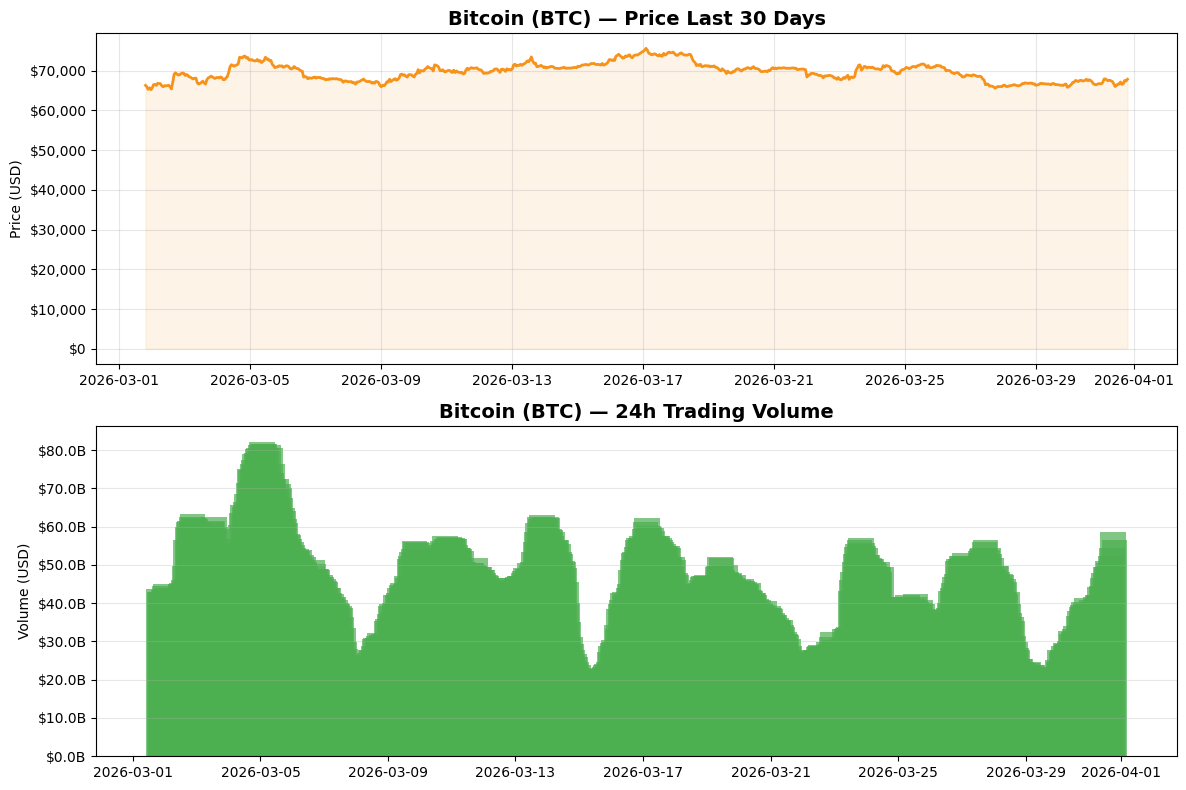

Chart saved as btc_price_volume.png


In [31]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
 
# --- Top chart: Price ---
axes[0].plot(df_btc_price["date"], df_btc_price["price"],
             color="#F7931A", linewidth=2)
axes[0].fill_between(df_btc_price["date"], df_btc_price["price"],
                     alpha=0.1, color="#F7931A")
axes[0].set_title("Bitcoin (BTC) — Price Last 30 Days", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Price (USD)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].grid(True, alpha=0.3)
 
# --- Bottom chart: Volume ---
axes[1].bar(df_btc_volume["date"], df_btc_volume["volume"],
            color="#4CAF50", alpha=0.7)
axes[1].set_title("Bitcoin (BTC) — 24h Trading Volume", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Volume (USD)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e9:.1f}B"))
axes[1].grid(True, alpha=0.3, axis="y")
 
plt.tight_layout()
plt.savefig("btc_price_volume.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as btc_price_volume.png")

Market chart fetched for bitcoin — 722 data points
Market chart fetched for ethereum — 722 data points
Market chart fetched for solana — 722 data points


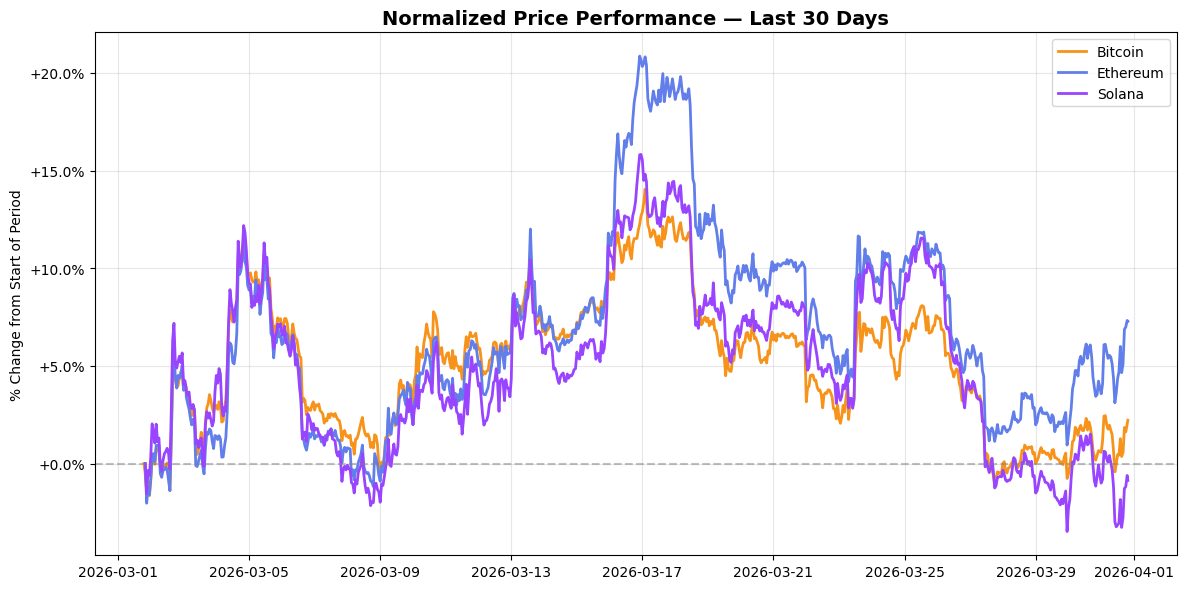

Comparison chart saved as coin_comparison.png


In [33]:
coin_list = ["bitcoin", "ethereum", "solana"]
colors    = {"bitcoin": "#F7931A", "ethereum": "#627EEA", "solana": "#9945FF"}
 
fig, ax = plt.subplots(figsize=(12, 6))
 
for coin in coin_list:
    df_price, _, _ = get_market_chart(coin, days=30)
 
    if df_price is not None:
        # Normalize: % change from first data point
        first_price           = df_price["price"].iloc[0]
        df_price["normalized"] = ((df_price["price"] - first_price) / first_price) * 100
 
        ax.plot(df_price["date"], df_price["normalized"],
                label=coin.capitalize(),
                color=colors.get(coin, None),
                linewidth=2)
 
    # Always sleep between CoinGecko calls to avoid rate limits
    time.sleep(2)
 
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)  # Zero baseline
ax.set_title("Normalized Price Performance — Last 30 Days", fontsize=14, fontweight="bold")
ax.set_ylabel("% Change from Start of Period")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:+.1f}%"))
ax.legend()
ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig("coin_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Comparison chart saved as coin_comparison.png")